# Figure 4 - Learning DendI weights for Dend Target Prop

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
figure_name = "Fig3_dendI"
model_list = ["bpLike_WT_fixedDend", "bpLike_WT_localBP", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Fixed random
Generating plots for Learned (Backprop)
Generating plots for Learned (Hebb)


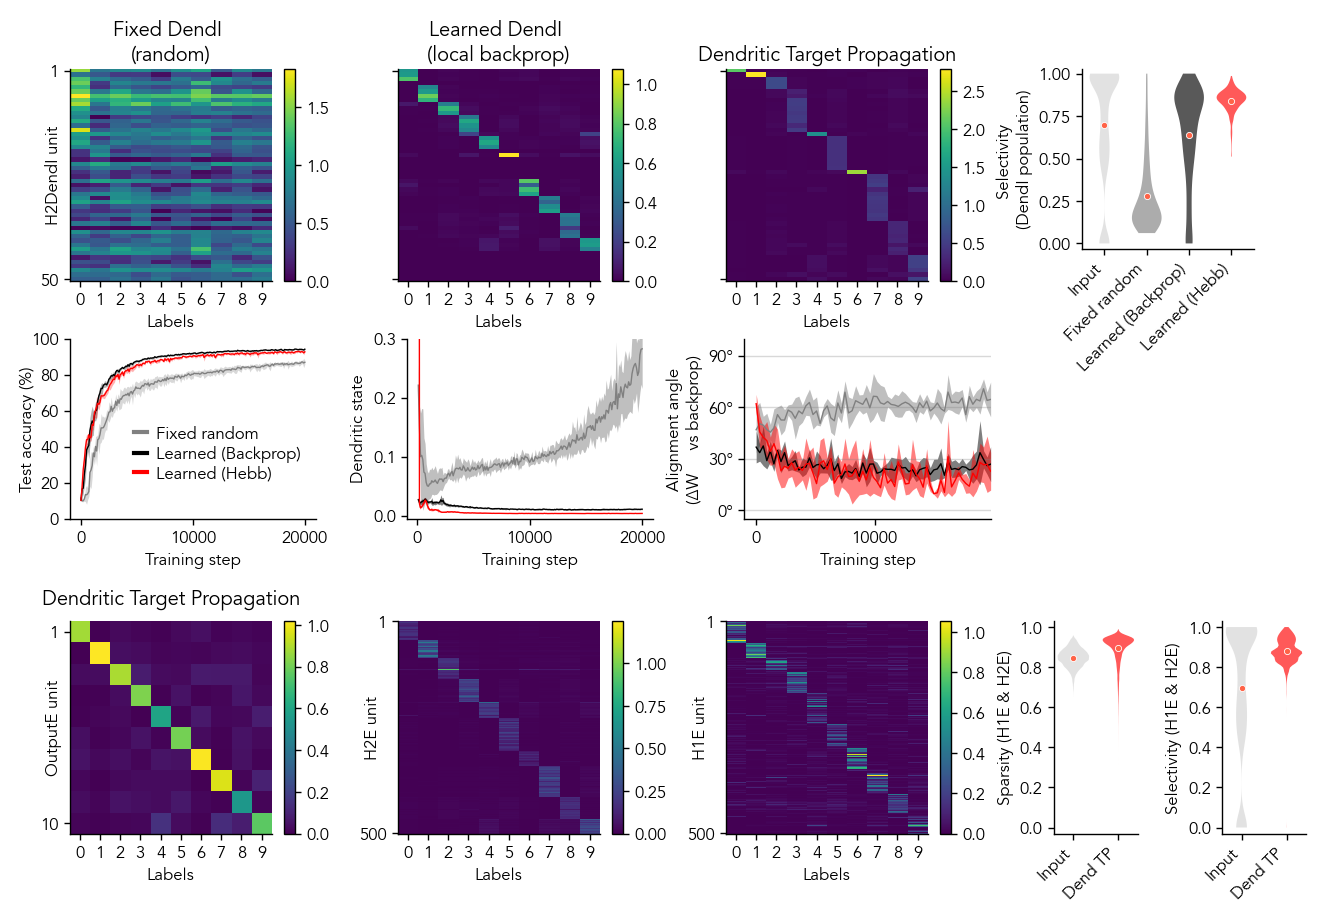

In [61]:
fig = plt.figure(figsize=(6.5, 4.5))
axes = gs.GridSpec(nrows=3, ncols=4, figure=fig,            
                    left=0.049,right=1,
                    top=0.95, bottom=0.1,
                    wspace=0.3, hspace=0.3)

metrics_axes = gs.GridSpec(nrows=3, ncols=4, figure=fig,
                    left=0.049,right=0.96,
                    top=0.95, bottom=0.15,
                    wspace=0.4, hspace=0.5,
                    width_ratios=[1, 1, 1, 0.7])
ax_selectivity = fig.add_subplot(metrics_axes[0, 3])
ax_accuracy    = fig.add_subplot(metrics_axes[1, 0])
ax_dendstate   = fig.add_subplot(metrics_axes[1, 1])
ax_angle       = fig.add_subplot(metrics_axes[1, 2])
root_dir = ut.get_project_root()

if "bpLike_WT_hebbdend" in model_dict_all: # Update model label for this figure
    model_dict_all["bpLike_WT_hebbdend"]["label"] = "Learned (Hebb)"
    
for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")
        populations_to_plot = ['H2DendI']
        example_seed = model_dict['seeds'][0] # example seed to plot

        # Plot heatmaps
        for row,population in enumerate(populations_to_plot):
            # Activity plots: batch accuracy of each population to the test dataset
            ax = fig.add_subplot(axes[row, col])
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            num_units = average_pop_activity_dict[population].shape[1]
            pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)
            ax.set_yticks([0,num_units-1])
            ax.set_yticklabels([1,num_units])
            ax.set_ylabel(f'{population} unit', labelpad=-8)
            if row==0:
                ax.set_title(model_dict["display_name"], pad=3)
            if col>0:
                ax.set_ylabel('')
                ax.set_yticklabels([])

        # Plot metrics
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy)
        plot_dendritic_state_all_seeds(data_dict, model_dict, ax=ax_dendstate)
        plot_angle_vs_bp_all_seeds(data_dict, model_dict, ax=ax_angle)

        populations_to_plot = [population for population in data_dict[example_seed]['average_pop_activity_dict'] if 'DendI' in population]
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin')
        ax_selectivity.set_ylabel(f"Selectivity \n(DendI population)")

        legend = ax_accuracy.legend(ncol=1, bbox_to_anchor=(0.2, 0.6), loc='upper left', fontsize=6)
        for line in legend.get_lines():
            line.set_linewidth(1.5)


        # Plot E cell heatmaps : Backprop vs DTP
        if model_key == "bpLike_WT_hebbdend":
            # Activity plots: batch accuracy of each population to the test dataset
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            for i, population in enumerate(["OutputE", "H2E", "H1E"]):
                ax = fig.add_subplot(axes[2, i])
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)
                num_units = average_pop_activity_dict[population].shape[1]
                ax.set_yticks([0,num_units-1])
                ax.set_yticklabels([1,num_units])
                ax.set_ylabel(f'{population} unit', labelpad=-8)
                if i==0:
                    ax.set_title("Dendritic Target Propagation")
            
            ax = gs.GridSpecFromSubplotSpec(1, 2, axes[2, 3], wspace=1)
            ax_sparsity = fig.add_subplot(ax[0])
            ax_selectivity = fig.add_subplot(ax[1])
            model_dict["label"] = "Dend TP"
            populations_to_plot = ['H1E', 'H2E']
            plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_sparsity, metric_name='sparsity', plot_type='violin', side='both')
            plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='both')
            ax_sparsity.set_ylabel(f"Sparsity ({' & '.join(populations_to_plot)})")
            ax_selectivity.set_ylabel(f"Selectivity ({' & '.join(populations_to_plot)})")

            # bar_width = 0.2
            # group_spacing = 0.5
            # within_group_spacing = 0.25
            # sparsity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            # selectivity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            # for seed in data_dict:
            #     for population in sparsity_all_seeds:
            #         avg_sparsity = np.mean(data_dict[seed][f"metrics_dict"][population]["sparsity"][:])
            #         sparsity_all_seeds[population].append(avg_sparsity)
            #         avg_selectivity = np.mean(data_dict[seed][f"metrics_dict"][population]["selectivity"][:])
            #         selectivity_all_seeds[population].append(avg_selectivity)

            # input_sparsity_data = sparsity_all_seeds['InputE']
            # input_selectivity_data = selectivity_all_seeds['InputE']
            # print(input_sparsity_data[0], input_selectivity_data[0])
            # if col == 0: # Plot InputE bar
            #     ax_sparsity.bar(0, np.mean(input_sparsity_data), color='gray', width=bar_width, alpha=0.5, 
            #                 error_kw={'ecolor': 'black', 'capsize': 3})
            #     ax_selectivity.bar(0, np.mean(input_selectivity_data), color='gray', width=bar_width, alpha=0.5, error_kw={'ecolor': 'black', 'capsize': 3})

            # x1 = group_spacing + col * within_group_spacing
            # x2 = 2 * group_spacing + (len(model_list) - 1)*within_group_spacing + col*within_group_spacing
            
            # ax_sparsity.bar(x1, np.mean(sparsity_all_seeds['H1E']), yerr=np.std(sparsity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            # ax_sparsity.bar(x2, np.mean(sparsity_all_seeds['H2E']), yerr=np.std(sparsity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            # ax_selectivity.bar(x1, np.mean(selectivity_all_seeds['H1E']), yerr=np.std(selectivity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            # ax_selectivity.bar(x2, np.mean(selectivity_all_seeds['H2E']), yerr=np.std(selectivity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)

            # h1e_center = group_spacing + (len(model_list) - 1) * within_group_spacing / 2
            # h2e_center = 2 * group_spacing + (len(model_list) - 1) * within_group_spacing + (len(model_list) - 1) * within_group_spacing / 2

            # ax_sparsity.set_xticks([0, h1e_center, h2e_center])
            # ax_sparsity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            # ax_sparsity.set_ylabel('Sparsity')
            # ax_sparsity.set_ylim([0.5, 1])
            # ax_sparsity.tick_params(axis='x', length=0)

            # ax_selectivity.set_xticks([0, h1e_center, h2e_center])
            # ax_selectivity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            # ax_selectivity.set_ylabel('Selectivity')
            # ax_selectivity.set_ylim([0.5, 1])
            # ax_selectivity.tick_params(axis='x', length=0)

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)